In [22]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df = \
    read_model_runs('../../data/processed/model-runs')



In [ ]:
from read_model_runs import filter_complete_questions

models = ['gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it']
firacs = ['FILA_', "FIRAC", 'FIR__', 'FI___', 'FIL__', '_____', 'unstructured']
question_long_df, question_wide_df, model_order, firac_order = filter_complete_questions(question_long_df, models, firacs)

print('shape:', question_long_df.shape)
print('# unique questions:', question_long_df['question_id'].nunique())
print("model order:", model_order)
print("firac order:", firac_order)


shape: (3164, 32)
# unique questions: 113
model order: ['gemma-3-4b-it', 'gemma-3n-e4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it']
firac order: ['unstructured', 'FIL__', '_____', 'FI___', 'FIR__', 'FILA_', 'FIRAC']


In [24]:
question_wide_df.head()

,question_id,model_name,unstructured,FIL__,_____,FI___,FIR__,FILA_,FIRAC
0,oab-1.pdf-006,gemma-3-12b-it,True,True,True,True,True,True,True
1,oab-1.pdf-006,gemma-3-27b-it,True,True,True,True,True,True,True
2,oab-1.pdf-006,gemma-3-4b-it,True,False,True,False,True,True,True
3,oab-1.pdf-006,gemma-3n-e4b-it,True,True,True,True,True,True,True
4,oab-10.pdf-094,gemma-3-12b-it,True,True,True,True,True,True,True


In [25]:
question_wide_df.columns

Index(['question_id', 'model_name', 'unstructured', 'FIL__', '_____', 'FI___',
       'FIR__', 'FILA_', 'FIRAC'],
      dtype='object')

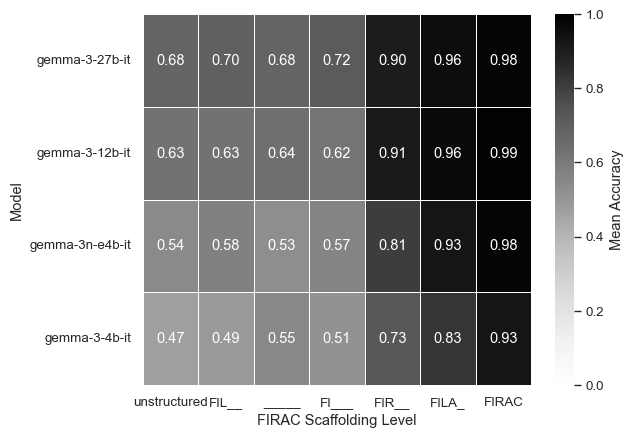

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Seleciona colunas FIRAC
# -----------------------------
firac_cols = [
    c for c in question_wide_df.columns
    if c not in ["question_id", "model_name"]
]

# -----------------------------
# 2. Wide -> Long
# -----------------------------
long_df = question_wide_df.melt(
    id_vars=["question_id", "model_name"],
    value_vars=firac_cols,
    var_name="firac_level",
    value_name="is_correct"
)

long_df["is_correct"] = long_df["is_correct"].astype(float)

# -----------------------------
# 3. Média por modelo × FIRAC
# -----------------------------
mean_acc = (
    long_df
    .groupby(["model_name", "firac_level"])["is_correct"]
    .mean()
    .reset_index()
)

# -----------------------------
# 4. Ordena modelos por acurácia média (↓)
# -----------------------------
model_order = (
    mean_acc
    .groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# -----------------------------
# 5. Pivot para heatmap
# -----------------------------
heatmap_df = mean_acc.pivot(
    index="model_name",
    columns="firac_level",
    values="is_correct"
)

heatmap_df = heatmap_df[firac_order]
heatmap_df = heatmap_df.loc[model_order]

# -----------------------------
# 6. Plot ACL-style
# -----------------------------
sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.1
)

plt.figure(figsize=(6.5, 4.5))

ax = sns.heatmap(
    heatmap_df,
    cmap="Greys",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Mean Accuracy"}
)

ax.set_xlabel("FIRAC Scaffolding Level")
ax.set_ylabel("Model")

plt.tight_layout()

# -----------------------------
# 7. Salva em PDF (ACL-ready)
# -----------------------------
plt.savefig(
    "../../reports/accuracy_heat_map.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


In [27]:
import pandas as pd

# =========================================================
# 1. Carrega planilha wide
# =========================================================
df = question_wide_df

firac_cols = firac_order

# Garante boolean
df[firac_cols] = df[firac_cols].astype(bool)

# =========================================================
# 2. Wide → Long
# =========================================================
long_df = df.melt(
    id_vars=["question_id", "model_name"],
    value_vars=firac_cols,
    var_name="firac",
    value_name="is_correct"
)

# =========================================================
# 3. Acurácia média por questão + FIRAC
# =========================================================
acc_df = (
    long_df
    .groupby(["question_id", "firac"])["is_correct"]
    .mean()
    .reset_index(name="accuracy")
)

# =========================================================
# 4. Acurácia → dificuldade (3 níveis)
# =========================================================
def accuracy_to_difficulty(acc):
    if acc > 0.75:
        return "easy"
    elif acc > 0.40:
        return "medium"
    else:
        return "hard"

acc_df["difficulty"] = acc_df["accuracy"].apply(accuracy_to_difficulty)


acc_df["firac"] = pd.Categorical(
    acc_df["firac"],
    categories=firac_order,
    ordered=True
)

# =========================================================
# 6. Exporta CSV para o R
# =========================================================
acc_df.to_csv(
    "../../data/processed/difficulty_by_question_firac.csv",
    index=False
)

print("CSV gerado: difficulty_by_question_firac.csv")


CSV gerado: difficulty_by_question_firac.csv


Executando script R...
✅ PDF e PNG gerados


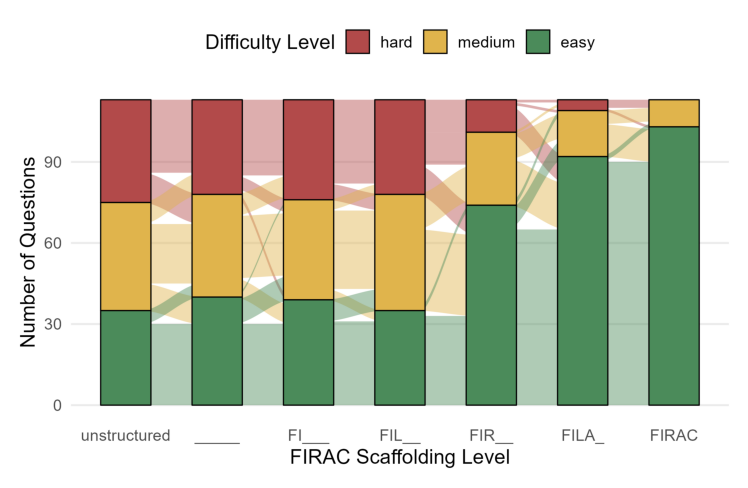

In [29]:
import subprocess
import textwrap
import tempfile
import os
import sys
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------------------------------------
# Caminhos
# ---------------------------------------------------------
CSV_PATH = "../../data/processed/difficulty_by_question_firac.csv"
PDF_PATH = "../../reports/alluvial_difficulty_firac.pdf"
PNG_PATH = "../../reports/alluvial_difficulty_firac.png"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV não encontrado: {CSV_PATH}")

# ---------------------------------------------------------
# Script R
# ---------------------------------------------------------
r_script = textwrap.dedent(f"""
    required_pkgs <- c("ggplot2", "ggalluvial", "dplyr", "readr", "Cairo")
    for (pkg in required_pkgs) {{
        if (!requireNamespace(pkg, quietly = TRUE)) {{
            install.packages(pkg, repos = "https://cloud.r-project.org")
        }}
    }}

    library(ggplot2)
    library(ggalluvial)
    library(dplyr)
    library(readr)
    library(Cairo)

    # -----------------------------
    # 1. Carrega CSV
    # -----------------------------
    df <- read_csv("{CSV_PATH}")

    # -----------------------------
    # 2. Ordens explícitas
    # -----------------------------
    firac_order <- c("unstructured", "_____", "FI___", "FIL__", "FIR__", "FILA_", "FIRAC")
    difficulty_order <- c("hard", "medium", "easy")

    df <- df %>%
      mutate(
        firac = factor(firac, levels = firac_order),
        difficulty = factor(difficulty, levels = difficulty_order)
      )

    # -----------------------------
    # 3. Alluvial plot (ACL-style)
    # -----------------------------
    p <- ggplot(
      df,
      aes(
        x = firac,
        stratum = difficulty,
        alluvium = question_id,
        fill = difficulty
      )
    ) +
      geom_flow(alpha = 0.45, curve_type = "cubic") +
      geom_stratum(width = 0.55, color = "black", linewidth = 0.4) +
      scale_fill_manual(
        values = c(
          "easy"   = "#4B8B5A",
          "medium" = "#E0B44C",
          "hard"   = "#B24A4A"
        )
      ) +
      labs(
        x = "FIRAC Scaffolding Level",
        y = "Number of Questions",
        fill = "Difficulty Level"
      ) +
      theme_minimal(base_size = 14) +
      theme(
        legend.position = "top",
        panel.grid.major.x = element_blank(),
        panel.grid.minor = element_blank()
      )

    # -----------------------------
    # 4. Salva PDF (ACL)
    # -----------------------------
    ggsave(
      "{PDF_PATH}",
      plot = p,
      width = 7,
      height = 4.5,
      device = cairo_pdf
    )

    # -----------------------------
    # 5. Salva PNG (visualização)
    # -----------------------------
    ggsave(
      "{PNG_PATH}",
      plot = p,
      width = 7,
      height = 4.5,
      dpi = 300
    )
""")

# ---------------------------------------------------------
# Executa R via Rscript
# ---------------------------------------------------------
with tempfile.NamedTemporaryFile(mode="w", suffix=".R", delete=False) as f:
    f.write(r_script)
    r_file = f.name

try:
    print("Executando script R...")
    subprocess.run(
        ["Rscript", r_file],
        check=True,
        capture_output=True,
        text=True
    )

    print("✅ PDF e PNG gerados")

    # -----------------------------------------------------
    # Mostra imagem na tela
    # -----------------------------------------------------
    img = Image.open(PNG_PATH)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

except subprocess.CalledProcessError as e:
    print("❌ Erro ao executar o R script")
    print(e.stderr)
    sys.exit(e.returncode)

finally:
    os.remove(r_file)
